In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Statistical Distribution

A distribution describes how values of a variable are spread and how likely each value is.

In [2]:
# create dummy data
np.random.seed(42)
x = np.random.rand(10)
x

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
       0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258])

In [5]:
# uniform distribution - means every value has equal probability.
from scipy import stats 
uni = stats.uniform.rvs(loc = 1, scale = 10, size = 1000000) # Random Variate Sample
uni

array([ 8.82998186,  4.47410332,  9.00172352, ...,  9.20192515,
       10.04737209,  2.37785159], shape=(1000000,))

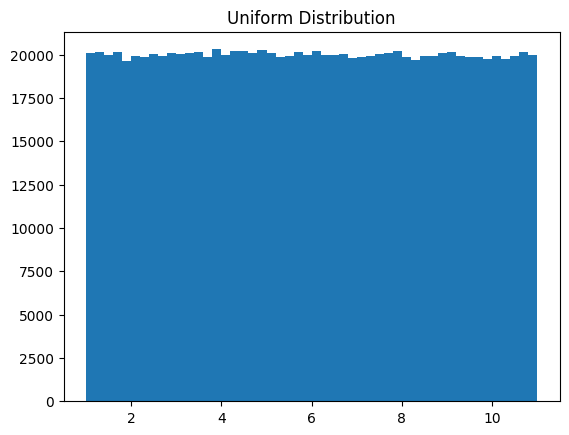

In [ ]:
plt.hist(uni, bins = 50) # density = True
plt.title('Uniform Distribution')
plt.show()

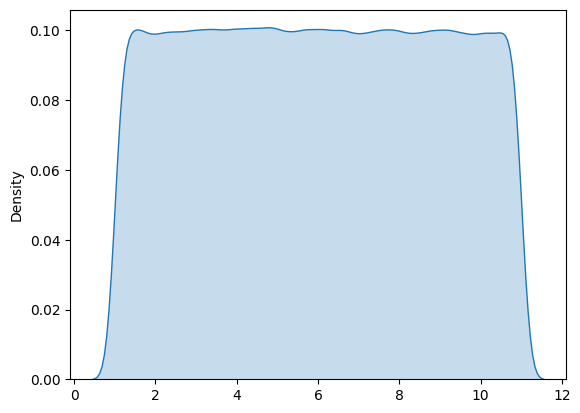

In [9]:
sns.kdeplot(uni, fill = True)
plt.show()

In [12]:
# CDF - cumulative distribution function - What is the probability that a value is less than or equal to X?
cdf = stats.uniform.cdf(x = 5, loc = 0, scale = 10) # There is a 50% chance the value is ≤ 5.
cdf

np.float64(0.5)

In [ ]:
# PPF - percent point function - Given probability → returns the cutoff value
rrf = stats.uniform.ppf(q = 0.3, loc = 0, scale = 10)
rrf # 30% of values lie below 3

np.float64(3.0)

In [ ]:
# Normal Distribution - 68–95–99.7 Rule
nor = stats.norm.rvs(loc = 0, scale = 1, size = 10000000) # loc = mean, scale = std
nor

array([-0.47448218, -0.847804  ,  0.21911136, ...,  0.43536499,
       -1.53324295,  0.84815912], shape=(10000000,))

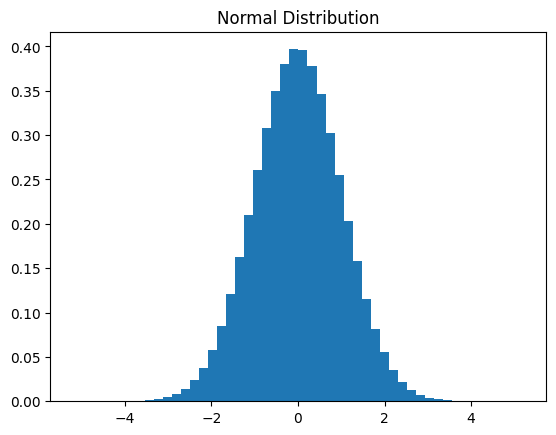

In [15]:
plt.hist(nor, bins=50, density=True)
plt.title("Normal Distribution")
plt.show()


In [ ]:
# normal cdf
stats.norm.cdf(0.4) # Probability that value ≤ 0.4

np.float64(0.6554217416103242)

In [ ]:
# normal ppf 
stats.norm.ppf(0.975) # 97.5% of values lie below this point

np.float64(1.959963984540054)

np.random.normal(1, 2, (3,2))   # mean=1, std=2

np.random.rand(3,2)            # uniform (0,1)

np.random.randn(3,2)           # standard normal


In [ ]:
# binomial distribution (pass/fail)(discrete n(number of trials), p(probability of success)) - Models the number of successes in a fixed number of trials.
coin = stats.binom.rvs(n=10, p=0.5, size=10000)
coin

array([4, 5, 8, ..., 6, 6, 5], shape=(10000,))

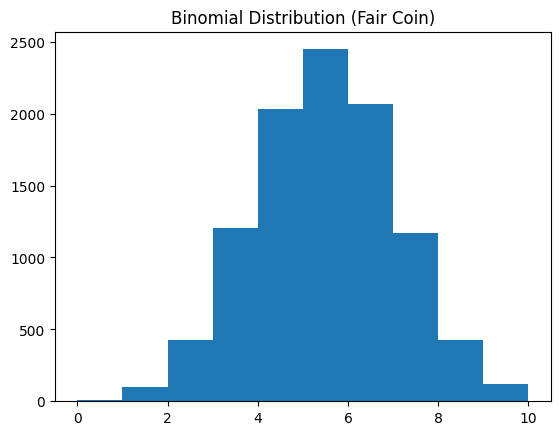

In [21]:
plt.hist(coin, bins=10)
plt.title("Binomial Distribution (Fair Coin)")
plt.show()


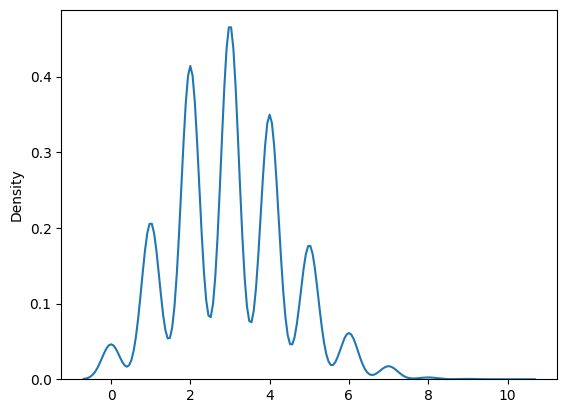

In [25]:
biased_coin = stats.binom.rvs(n=10, p=0.3, size=10000)
sns.kdeplot(biased_coin)
plt.show()

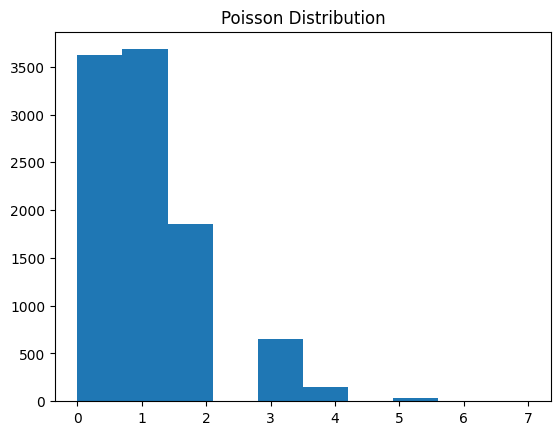

In [ ]:
# poisson distribution (clicks/visits) ( event counts )(data discrete - Mean=Variance=λ) - Models number of times an event occurs in a fixed interval.
arrivals = stats.poisson.rvs(mu=1, size=10000)
plt.hist(arrivals, bins=10)
plt.title("Poisson Distribution")
plt.show()


Geometrirc Distibution - “How many attempts until the first success?”. How many coin flips until first head? generally right skewed, only discrete.

Exponetial Distribution - continuos version of geometric How long do I wait until an event happens?”

# Normality Testing - 
A normal distribution looks like a bell curve:
Centered around the mean.
Left and right sides are symmetric.
Most ML algorithms assume this shape.

How do we check - 1. visual methods (histogram, kde plot, Q-Q plot). 2. statistical tests (shapiro-wilk test, kolmogorov-smirnov test, anderson-darling test) if p-value > 0.05, data is normal else p-value < or equal to 0.05 then not normal.

Outlier Detection generally use IQR, but Standardization (Z-Score) only applied if data noramal


In [125]:
np.random.seed(42)
n = 200_00_00
price = np.random.lognormal(mean = 3.5, sigma = 0.5, size = n)
sales = np.random.poisson(lam = 20, size = n)
revenue = price * sales
df = pd.DataFrame({
    "Price": price,
    "Sales": sales,
    "Revenue": revenue
})

In [126]:
df.head(2)

,Price,Sales,Revenue
0,42.451280,18,764.123048
1,30.903451,16,494.455211


In [30]:
df.describe()

,Price,Sales,Revenue
count,2.000000e+06,2.000000e+06,2.000000e+06
mean,3.751363e+01,2.000052e+01,7.503525e+02
std,2.000263e+01,4.473421e+00,4.430785e+02
min,2.960274e+00,3.000000e+00,3.613548e+01
25%,2.361864e+01,1.700000e+01,4.454223e+02
50%,3.310879e+01,2.000000e+01,6.469995e+02
75%,4.638059e+01,2.300000e+01,9.373561e+02
max,3.701141e+02,4.700000e+01,9.105435e+03


In [127]:
df['Revenue'].skew()

np.float64(1.9159578703435716)

In [76]:
df['Price'].skew()

np.float64(1.7453697260852539)

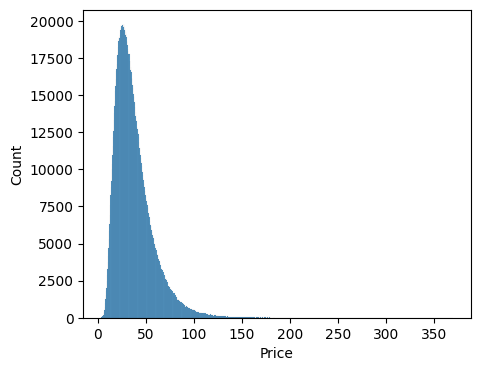

In [38]:
plt.figure(figsize=(5,4))
sns.histplot(data=df, x = 'Price')
plt.show()

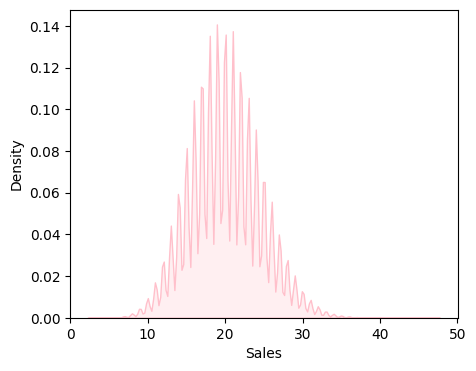

In [42]:
plt.figure(figsize=(5,4))
sns.kdeplot(data=df, x = 'Sales', fill = True, color = 'pink')
plt.show()

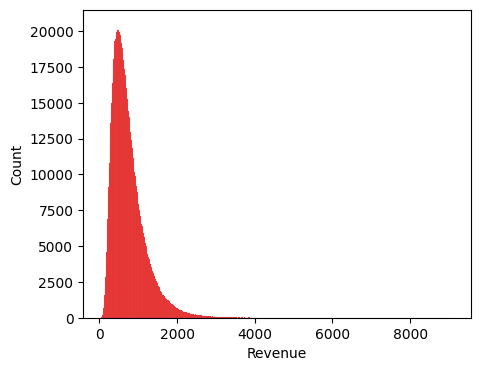

In [43]:
plt.figure(figsize=(5,4))
sns.histplot(data=df, x = 'Revenue', color = 'red')
plt.show()

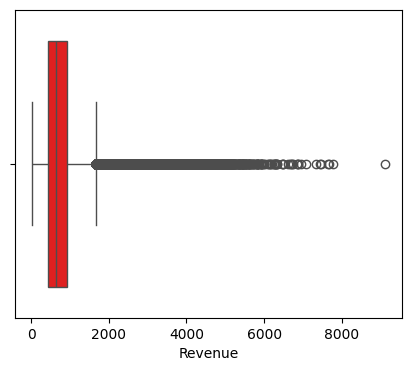

In [57]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x = 'Revenue', color = 'red')
plt.show()

In [128]:
# shapiro wilk - p ≤ 0.05 → Not Normally Distributed, The closer this number is to 1.0, the more "Normal" the data looks.
sample = df['Revenue'].sample(5000, random_state=42)
stat, p_value = stats.shapiro(sample)
print("Shapiro Test Statistic:", stat)
print("p-value:", p_value)

Shapiro Test Statistic: 0.843195893954593
p-value: 4.4263247007877713e-57


In [129]:
# Kolmogorov–Smirnov Test
stat, p_value = stats.kstest(sample, 'norm', args = (sample.mean(), sample.std()))
print("KS Test Statistic:", stat)
print("p-value:", p_value)

KS Test Statistic: 0.12291057109155379
p-value: 2.736912065380776e-66


In [133]:
from scipy.stats import anderson

result = anderson(sample, dist='norm', method = 'interpolate')
print(result.pvalue)


0.01


In [134]:
from scipy.stats import MonteCarloMethod

mc = MonteCarloMethod(n_resamples=1000)

result = anderson(sample, dist='norm', method=mc)
print(result.pvalue)


0.000999000999000999


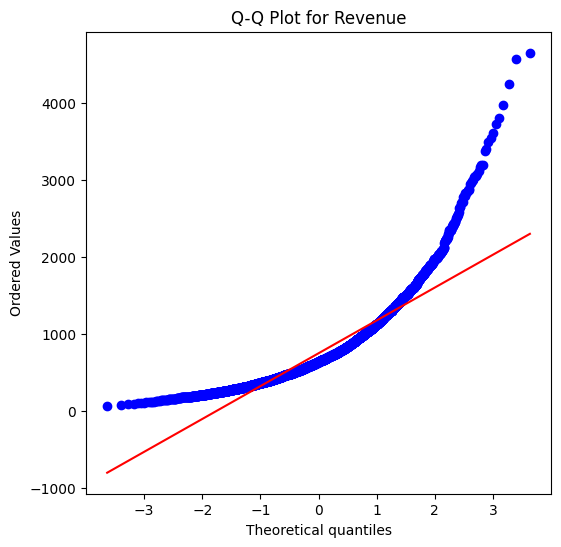

In [ ]:
# Quantile-Quantile Plot - right skewed
plt.figure(figsize=(6,6))
stats.probplot(sample, dist="norm", plot=plt)
plt.title("Q-Q Plot for Revenue")
plt.show()


In [51]:
# Calculate IQR
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
print(Q1)
print(Q3)
print(IQR)

445.4222871717559
937.3560732448511
491.93378607309523


In [53]:
lower_mild = Q1 - 1.5 * IQR
upper_mild = Q3 + 1.5 * IQR
print(lower_mild)
print(upper_mild)
lower_extreme = Q1 - 3.0 * IQR
upper_extreme = Q3 + 3.0 * IQR
print(lower_extreme)
print(upper_extreme)

-292.47839193788695
1675.256752354494
-1030.3790710475298
2413.1574314641366


In [56]:
mild_outliers = df[((df['Revenue'] < lower_mild) & (df['Revenue'] > lower_extreme)) | ((df['Revenue'] > upper_mild) & (df['Revenue'] <= upper_extreme))]
extreme_outliers = df[
    (df['Revenue'] < lower_extreme) |
    (df['Revenue'] > upper_extreme)
]

print("Mild Outliers:", mild_outliers.shape[0])
print("Extreme Outliers:", extreme_outliers.shape[0])

Mild Outliers: 66187
Extreme Outliers: 15544


In [58]:
cap = df['Revenue'].quantile(0.99)
cap

np.float64(2294.944622906514)

In [59]:
# capping (winsorization)
df['Revenue_Cap'] = df['Revenue'].clip(lower = lower_mild, upper= upper_mild)

In [69]:
df.head(2)

,Price,Sales,Revenue,Revenue_Cap
0,42.451280,18,764.123048,764.123048
1,30.903451,16,494.455211,494.455211


In [70]:
# Compare the original and capped data
print(df[['Revenue', 'Revenue_Cap']].describe())

            Revenue   Revenue_Cap
count  2.000000e+06  2.000000e+06
mean   7.503525e+02  7.318666e+02
std    4.430785e+02  3.789572e+02
min    3.613548e+01  3.613548e+01
25%    4.454223e+02  4.454223e+02
50%    6.469995e+02  6.469995e+02
75%    9.373561e+02  9.373561e+02
max    9.105435e+03  1.675257e+03


In [61]:
# Take a sample of the capped data
sample_cap = df['Revenue_Cap'].sample(5000, random_state=42)
stat_cap, p_val_cap = stats.shapiro(sample_cap)

print("New Shapiro Statistic:", stat_cap)
print("New p-value:", p_val_cap)

New Shapiro Statistic: 0.9193829598601502
New p-value: 1.1820238715324779e-45


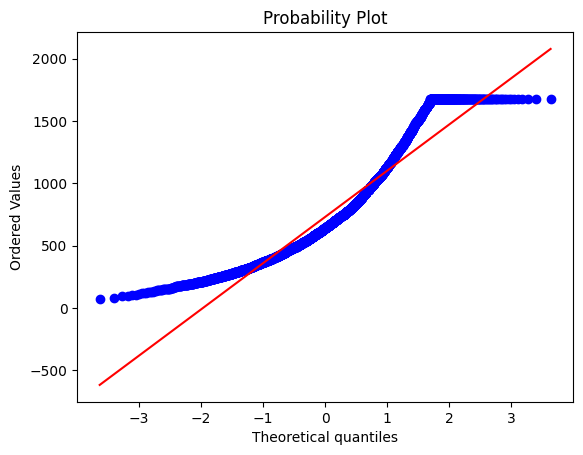

In [ ]:
# Q-Q plot
stats.probplot(sample_cap, dist = 'norm', plot = plt)
plt.show()

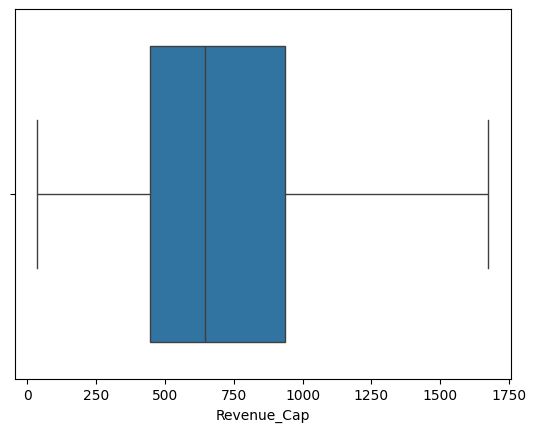

In [72]:
sns.boxplot(data = df, x = 'Revenue_Cap')
plt.show()

In [135]:
# Standardization (Z-Score) 
order_value = np.random.normal(
    loc=1000,   # mean
    scale=150,  # standard deviation
    size=n
)

df1 = pd.DataFrame({
    "Order_Value": order_value
})

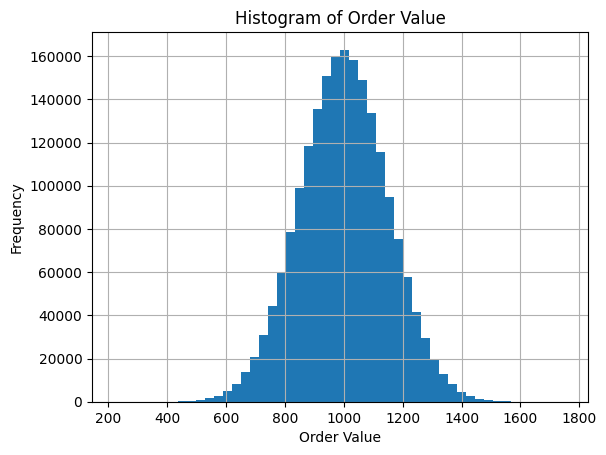

In [136]:
df1['Order_Value'].hist(bins=50)
plt.title("Histogram of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()


In [137]:
from scipy import stats
sample = df1.sample(500, random_state=42)
stat, p_value = stats.shapiro(sample)
print("stat:",stat)
print("p-value:",p_value)

stat: 0.9967993227037547
p-value: 0.42951626757814093


In [138]:
mean = df1['Order_Value'].mean()
std = df1['Order_Value'].std()

df1['Order_Value_Z'] = (df1['Order_Value'] - mean) / std


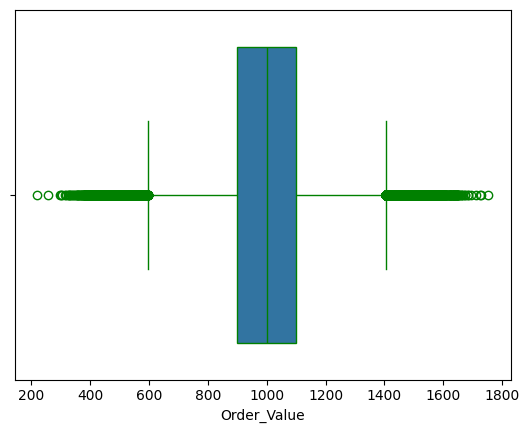

In [139]:
sns.boxplot(data = df1, x = 'Order_Value', linecolor='green', linewidth=1.0)
plt.show()

In [140]:
df1['Z_Outlier'] = df1['Order_Value_Z'].abs() > 3


In [141]:
df1['Z_Outlier'].value_counts()


Z_Outlier
False    1994600
True        5400
Name: count, dtype: int64

In [142]:
df1[df1['Z_Outlier']].head()


,Order_Value,Order_Value_Z,Z_Outlier
54,1456.701999,3.043798,True
425,481.504503,-3.456924,True
579,1460.785210,3.071017,True
782,549.698369,-3.002339,True
1159,1451.537238,3.009370,True


In [145]:
upper_cap = mean + 3 * std
lower_cap = mean - 3 * std


In [146]:
# df_clean = df[df['Z_Outlier'] == False]
# capping
df1['Order_Value_Capped'] = df1['Order_Value'].clip(
    lower=lower_cap,
    upper=upper_cap
)


In [147]:
df1.head(2)

,Order_Value,Order_Value_Z,Z_Outlier,Order_Value_Capped
0,869.545451,-0.870221,False,869.545451
1,1138.119605,0.920110,False,1138.119605


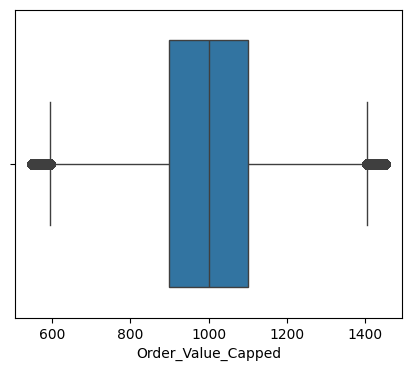

In [148]:
plt.figure(figsize=(5, 4))
sns.boxplot(data = df1, x = 'Order_Value_Capped')
plt.show()

In [149]:
# correlation, covariance, causation
df1.describe()

,Order_Value,Order_Value_Z,Order_Value_Capped
count,2.000000e+06,2.000000e+06,2.000000e+06
mean,1.000090e+03,-1.193143e-16,1.000091e+03
std,1.500137e+02,1.000000e+00,1.496336e+02
min,2.207108e+02,-5.195389e+00,5.500493e+02
25%,8.987479e+02,-6.755553e-01,8.987479e+02
50%,9.999867e+02,-6.916018e-04,9.999867e+02
75%,1.101236e+03,6.742450e-01,1.101236e+03
max,1.753307e+03,5.020983e+00,1.450132e+03


In [150]:
df.describe()

,Price,Sales,Revenue
count,2.000000e+06,2.000000e+06,2.000000e+06
mean,3.751363e+01,2.000052e+01,7.503525e+02
std,2.000263e+01,4.473421e+00,4.430785e+02
min,2.960274e+00,3.000000e+00,3.613548e+01
25%,2.361864e+01,1.700000e+01,4.454223e+02
50%,3.310879e+01,2.000000e+01,6.469995e+02
75%,4.638059e+01,2.300000e+01,9.373561e+02
max,3.701141e+02,4.700000e+01,9.105435e+03


In [151]:
cor = df.corr()
cor

,Price,Sales,Revenue
Price,1.000000,0.000673,0.903273
Sales,0.000673,1.000000,0.379303
Revenue,0.903273,0.379303,1.000000


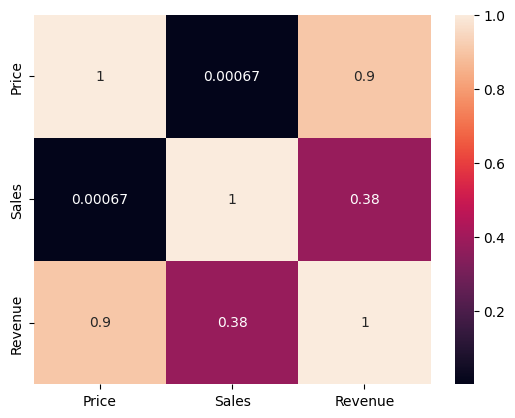

In [154]:
sns.heatmap(cor, annot =True)
plt.show()

In [ ]:
%pip install sklearn

In [ ]:
%pip install statsmodels

In [ ]:
%pip install statsmodels scikit-learn

In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

In [ ]:
# If you haven't cleaned your outliers yet, Pearson will lie to you. Always use Spearman for raw, messy data.
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    "Price": np.random.normal(50, 10, n),
    "Sales": np.random.poisson(20, n),
    "Revenue": np.random.normal(1000, 300, n),
    "Discount": np.random.uniform(5, 15, n),
    "Gender": np.random.choice(['Male', 'Female'], n),
    "Product_Category": np.random.choice(['A', 'B', 'C'], n)
})
df['Revenue'] = df['Price'] * df['Sales']
pearson_corr = df[['Price','Sales','Revenue','Discount']].corr(method='pearson')
spearman_corr = df[['Price','Sales','Revenue','Discount']].corr(method='spearman')

print("Pearson Correlation:\n", pearson_corr) # Normally Distributed
print("\nSpearman Correlation:\n", spearman_corr)

Pearson Correlation:
              Price     Sales   Revenue  Discount
Price     1.000000 -0.011428  0.628943 -0.013676
Sales    -0.011428  1.000000  0.757067 -0.033894
Revenue   0.628943  0.757067  1.000000 -0.039038
Discount -0.013676 -0.033894 -0.039038  1.000000

Spearman Correlation:
              Price     Sales   Revenue  Discount
Price     1.000000 -0.017196  0.623723 -0.009994
Sales    -0.017196  1.000000  0.734802 -0.034161
Revenue   0.623723  0.734802  1.000000 -0.036878
Discount -0.009994 -0.034161 -0.036878  1.000000


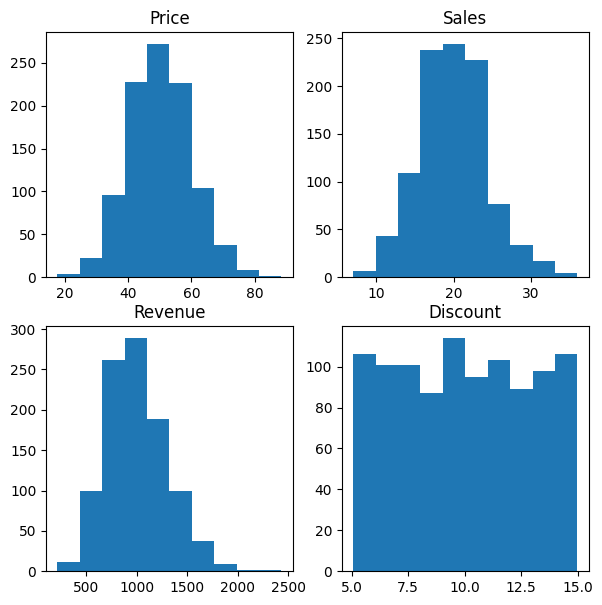

In [175]:
fig, ax = plt.subplots(2,2, figsize = (7,7))
ax[0,0].hist(df['Price'])
ax[0,0].set_title('Price')
ax[0,1].hist(df['Sales'])
ax[0,1].set_title('Sales')
ax[1,0].hist(df['Revenue'])
ax[1,0].set_title('Revenue')
ax[1,1].hist(df['Discount'])
ax[1,1].set_title('Discount')
plt.show()

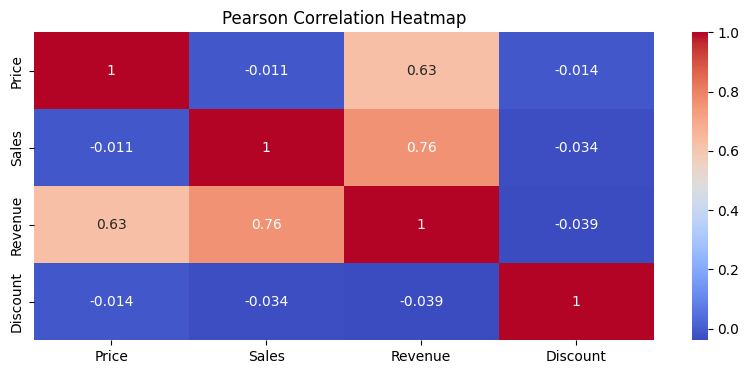

In [169]:
plt.figure(figsize=(10,4))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()


Chi-Square Test

In [176]:
np.random.seed(42)
data = pd.DataFrame({
    "Gender": np.random.choice(["Male", "Female"], size=500),
    "Product": np.random.choice(["Electronics", "Clothing", "Books"], size=500)
})

In [177]:
data.head(2)

,Gender,Product
0,Male,Books
1,Female,Electronics


In [ ]:
table = pd.crosstab(data['Gender'], data['Product'])
table # observed frequency

Product,Books,Clothing,Electronics
Gender,,,
Female,76,86,94
Male,72,80,92


In [180]:
from scipy.stats import chi2_contingency

df=(r−1)(c−1) - degree of freedom

In [181]:
chi2_stat, p_value, dof, expected = chi2_contingency(table)
print("Chi-Square Statistic:", chi2_stat)
print("Degrees of Freedom:", dof)
print("P-value:", p_value)

Chi-Square Statistic: 0.058514658775166484
Degrees of Freedom: 2
P-value: 0.9711665226227854


In [ ]:
# expected frequency - assumes no relationship exists
expected_df = pd.DataFrame(expected, index= table.index, columns = table.columns)
expected_df

Product,Books,Clothing,Electronics
Gender,,,
Female,75.776,84.992,95.232
Male,72.224,81.008,90.768


In [186]:
alpha = 0.05
if p_value < alpha:
   print("Reject H0, Significant relationship exists..")
else:
    print("Fail to reject H0, No Significant relationship..")

Fail to reject H0, No Significant relationship..


In [ ]:
# If χ² > critical value → Reject H₀
from scipy.stats import chi2
critical_value = chi2.ppf(0.95, dof)
critical_value


np.float64(5.991464547107979)

VIF - (Variance Inflation Factor) - When we use many input variables, are some of them basically saying the same thing?
If yes → model gets confused
That confusion is called multicollinearity
VIF is just a confusion meter.

Can I predict Total Science using Maths + Physics?

| VIF value | Meaning in simple words |
| --------- | ----------------------- |
| 1         | Unique, no overlap      |
| 1–5       | Some overlap (okay)     |
| 5–10      | Strong overlap ⚠        |
| >10       | Almost duplicate ❌      |

VIF checks multicollinearity by measuring how well a feature can be explained using other features. A high VIF means the feature is redundant and its coefficient becomes unstable.


In [192]:
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True)
df = data.frame

In [193]:
df.head(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0


In [194]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [195]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')

In [196]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [198]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [199]:
X = df.drop(columns=['target'])
X = add_constant(X)

In [205]:
X.columns

Index(['const', 'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str')

In [206]:
X['const'].unique()

array([1.])

Rule used in real projects:

VIF > 5 → problematic

VIF > 10 → must act

In [207]:
vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df

,Feature,VIF
0,const,1.000000
1,age,1.217307
2,sex,1.278071
3,bmi,1.509437
4,bp,1.459428
5,s1,59.202510
6,s2,39.193370
7,s3,15.402156
8,s4,8.890986
9,s5,10.075967


In [214]:
X_reduced = X.drop(columns=['s1', 's2'])


In [215]:
X_reduced.head(2)

,const,age,sex,bmi,bp,s3,s4,s5,s6
0,1.0,0.038076,0.050680,0.061696,0.021872,-0.043401,-0.002592,0.019907,-0.017646
1,1.0,-0.001882,-0.044642,-0.051474,-0.026328,0.074412,-0.039493,-0.068332,-0.092204


In [216]:
vif_df = pd.DataFrame()
vif_df["Feature"] = X_reduced.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_reduced.values, i)
    for i in range(X_reduced.shape[1])
]

vif_df


,Feature,VIF
0,const,1.000000
1,age,1.207546
2,sex,1.274705
3,bmi,1.486750
4,bp,1.454393
5,s3,2.430240
6,s4,3.154782
7,s5,1.975611
8,s6,1.484007
